In [1]:
!pip install opencv-python


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [3]:
dataset_path = 'Brain_Tumor_Dataset'

In [4]:
yes_path = os.path.join(dataset_path, "yes")
no_path = os.path.join(dataset_path, "no")

print("Tumor Images :", len(os.listdir(yes_path)))
print("No Tumor Images :", len(os.listdir(no_path)))

Tumor Images : 155
No Tumor Images : 98


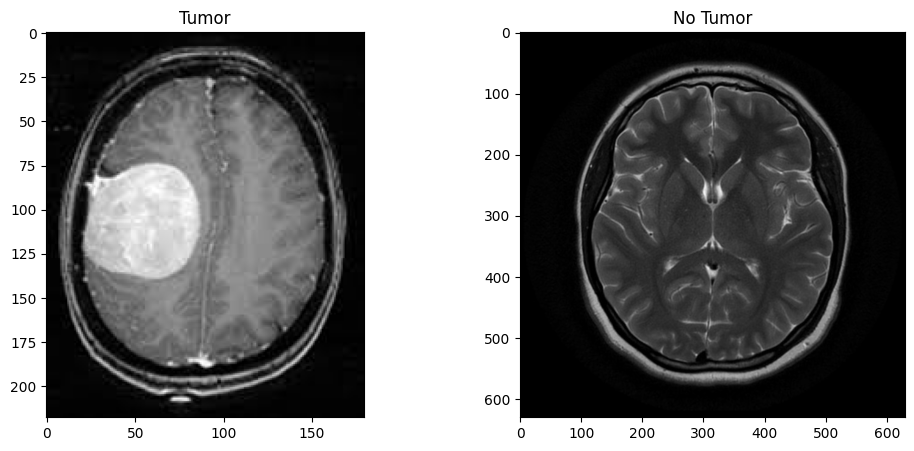

In [5]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
img = cv2.imread(os.path.join(yes_path, os.listdir(yes_path)[0]))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Tumor")

plt.subplot(1,2,2)
img = cv2.imread(os.path.join(no_path, os.listdir(no_path)[0]))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("No Tumor")

plt.show()

In [6]:
IMG_SIZE = 224

images = []
labels = []

In [7]:
for image_name in os.listdir(yes_path):

    image_path = os.path.join(yes_path, image_name)

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    image = image / 255.0

    images.append(image)

    labels.append(1)

In [8]:
for image_name in os.listdir(no_path):

    image_path = os.path.join(no_path, image_name)

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    image = image / 255.0

    images.append(image)

    labels.append(0)

In [9]:
X = np.array(images)

y = np.array(labels)

print("Image Dataset Shape :", X.shape)

print("Label Shape :", y.shape)

Image Dataset Shape : (253, 224, 224, 3)
Label Shape : (253,)


In [10]:
print("Tumor Images :", np.sum(y == 1))

print("No Tumor Images :", np.sum(y == 0))

Tumor Images : 155
No Tumor Images : 98


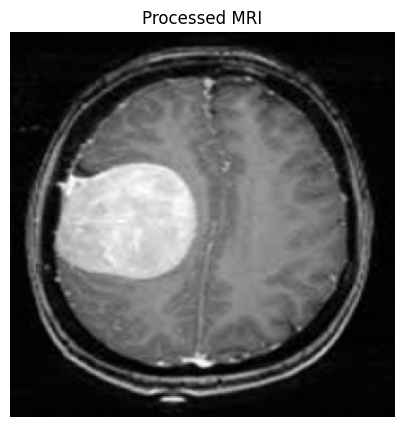

In [11]:
plt.figure(figsize=(5,5))

plt.imshow(X[0])

plt.title("Processed MRI")

plt.axis("off")

plt.show()

In [12]:
from sklearn.model_selection import train_test_split

# First split into Train (80%) and Temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Split Temp into Validation (10%) and Test (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training Images   :", X_train.shape)
print("Validation Images :", X_val.shape)
print("Testing Images    :", X_test.shape)

Training Images   : (202, 224, 224, 3)
Validation Images : (25, 224, 224, 3)
Testing Images    : (26, 224, 224, 3)


In [13]:
print("Training Labels   :", y_train.shape)
print("Validation Labels :", y_val.shape)
print("Testing Labels    :", y_test.shape)

Training Labels   : (202,)
Validation Labels : (25,)
Testing Labels    : (26,)


In [14]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [15]:
train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=16,
    shuffle=True
)

In [16]:
images_batch, labels_batch = next(train_generator)

print(images_batch.shape)
print(labels_batch.shape)

(16, 224, 224, 3)
(16,)


In [17]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

In [18]:
base_model.trainable = False

print("Base model loaded successfully!")

Base model loaded successfully!


In [19]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [21]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [27]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [28]:
history = model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 429ms/step - accuracy: 0.9257 - loss: 0.2199 - val_accuracy: 1.0000 - val_loss: 0.0977
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 431ms/step - accuracy: 0.9307 - loss: 0.2219 - val_accuracy: 1.0000 - val_loss: 0.0992
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 404ms/step - accuracy: 0.8911 - loss: 0.2325 - val_accuracy: 1.0000 - val_loss: 0.0903
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 425ms/step - accuracy: 0.8911 - loss: 0.2545 - val_accuracy: 1.0000 - val_loss: 0.0918
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 433ms/step - accuracy: 0.9208 - loss: 0.2138 - val_accuracy: 1.0000 - val_loss: 0.0962
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 440ms/step - accuracy: 0.9257 - loss: 0.2271 - val_accuracy: 1.0000 - val_loss: 0.0891
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 397ms/step - accuracy: 0.9158 - loss: 0.2320 - val_accuracy: 1.0000 - val_loss: 0.0886
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 377ms/step - accuracy: 0.9406 - loss: 0.1800 - val_accuracy: 1

In [29]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step - accuracy: 0.8846 - loss: 0.2898
Test Loss : 0.2898394763469696
Test Accuracy : 0.8846153616905212


In [30]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

y_pred = y_pred.flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 8  2]
 [ 1 15]]


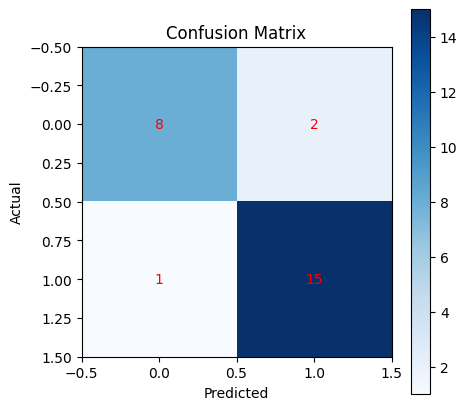

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha="center",
                 va="center",
                 color="red")

plt.show()

In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

Precision : 0.8823529411764706
Recall : 0.9375
F1 Score : 0.9090909090909091


In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.88      0.94      0.91        16

    accuracy                           0.88        26
   macro avg       0.89      0.87      0.88        26
weighted avg       0.88      0.88      0.88        26



In [35]:
model.save("brain_tumor_model.keras")

print("Model Saved Successfully!")

Model Saved Successfully!
